In [38]:
from dotenv import load_dotenv

load_dotenv()

True

In [39]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model='text-embedding-3-large')

In [40]:
# 백터DB 불러오기
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore
import os

index_name = 'tax-index'
pinecone_api_key = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=pinecone_api_key)

vectorstore = PineconeVectorStore(
    index_name=index_name,
    embedding=embedding
)

In [41]:
query = "연봉 5천만원 거주자의 소득세는 얼마인가요"

retriever = vectorstore.as_retriever(search_kwargs={'k':2})
retriever.invoke(query)

[Document(id='c38d3e74-289d-4886-94c4-f527c7bdd39e', metadata={'source': './data/tax.docx'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n| 종합소득 과세표준          | 세율                                         |\n\n|-------------------|--------------------------------------------|\n\n| 1,400만원 이하     | 과세표준의 6퍼센트                             |\n\n| 1,400만원 초과     5,000만원 이하     | 84만원 + (1,400만원을 초과하는 금액의 15퍼센트)  |\n\n| 5,000만원 초과   8,800만원 이하     | 624만원 + (5,000만원을 초과하는 금액의 24퍼센트) |\n\n| 8,800만원 초과 1억5천만원 이하    | 3,706만원 + (8,800만원을 초과하는 금액의 35퍼센트)|\n\n| 1억5천만원 초과 3억원 이하         | 3,706만원 + (1억5천만원을 초과하는 금액의 38퍼센트)|\n\n| 3억원 초과    5억원 이하         | 9,406만원 + (3억원을 초과하는 금액의 38퍼센트)   |\n\n| 5억원 초과      10억원 이하        | 1억 7,406만원 + (5억원을 초과하는 금액의 42퍼센트)|\n\n| 10억원 초과        | 3억 8,406만원 + (10억원을 초과하는 금액의 45퍼센트)|\n\n\n\n\n\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 

In [42]:
from typing_extensions import List,TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query : str
    context : List[Document]
    answer : str
    

In [43]:
def retrieve(state: AgentState) -> AgentState:
    """ 사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다. """
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [44]:
def generate(state: AgentState) -> AgentState:
    """ 주어진 state를 기반으로 RAG 체인을 사용하여 응답을 생성합니다. """
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser

    query = state['query']
    context = state['context']
    context_text = "\n\n".join([doc.page_content for doc in context])

    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 세법 전문가입니다. 주어진 세법 문서를 바탕으로 사용자의 질문에 정확하게 답변하세요.
문서에 없는 내용은 답변하지 마세요.

[세법 문서]
{context}"""),
        ("human", "{query}")
    ])

    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    chain = prompt | llm | StrOutputParser()

    answer = chain.invoke({'context': context_text, 'query': query})
    return {'answer': answer}

In [45]:
class GradeHallucination(BaseModel):
    """답변이 문서에 근거하는지 판단 결과"""
    score: str = Field(description="답변이 문서에 근거하면 'yes', 근거하지 않으면 'no'")

def check_hallucination(state: AgentState) -> Literal['not_hallucinated', 'generate']:
    """ 생성된 답변이 검색된 문서에 근거하는지 판단합니다. """
    context = state['context']
    answer = state['answer']
    context_text = "\n\n".join([doc.page_content for doc in context])

    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 AI가 생성한 답변이 주어진 문서에 근거하는지 판단하는 평가자입니다.
답변이 문서의 내용에만 기반하면 'yes', 문서에 없는 내용을 포함(환각)하면 'no'로 답하세요.

[문서]
{context}"""),
        ("human", "답변: {answer}\n\n이 답변이 문서에 근거합니까?")
    ])

    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    structured_llm = llm.with_structured_output(GradeHallucination)
    chain = prompt | structured_llm

    result = chain.invoke({'context': context_text, 'answer': answer})

    if result.score == 'yes':
        print("--- 환각 검사: 문서 근거 있음 → 최종 답변 반환 ---")
        return 'not_hallucinated'
    else:
        print("--- 환각 검사: 환각 감지 → 답변 재생성 ---")
        return 'generate'

In [46]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class GradeDocuments(BaseModel):
    """검색된 문서의 관련성 판단 결과"""
    score: str = Field(description="문서가 질문과 관련 있으면 'yes', 없으면 'no'")

def check_doc_relevence(state: AgentState) -> Literal['generate', 'rewrite']:
    """ 주어진 state를 기반으로 문서의 관련성을 판단합니다. """
    query = state['query']
    context = state['context']
    context_text = "\n\n".join([doc.page_content for doc in context])

    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 검색된 문서가 사용자의 질문과 관련이 있는지 판단하는 평가자입니다.
문서가 질문에 답변하는 데 도움이 되면 'yes', 그렇지 않으면 'no'로 답하세요.

[검색된 문서]
{context}"""),
        ("human", "질문: {query}\n\n이 문서가 질문과 관련이 있습니까?")
    ])

    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    structured_llm = llm.with_structured_output(GradeDocuments)
    chain = prompt | structured_llm

    result = chain.invoke({'context': context_text, 'query': query})

    if result.score == 'yes':
        print("--- 문서 관련성: 관련 있음 → generate ---")
        return 'generate'
    else:
        print("--- 문서 관련성: 관련 없음 → rewrite ---")
        return 'rewrite'

In [47]:
def rewrite(state: AgentState) -> AgentState:
    """ 사용자의 질문을 사전을 고려하여 질문을 변경합니다. """
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser

    query = state['query']

    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 세법 검색 전문가입니다. 사용자의 질문을 세법 문서에서 더 잘 검색될 수 있도록 개선하세요.
- 세법 용어를 정확히 사용하세요
- 핵심 키워드를 포함하세요
- 질문만 출력하고 설명은 하지 마세요"""),
        ("human", "원래 질문: {query}\n\n개선된 질문:")
    ])

    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    chain = prompt | llm | StrOutputParser()

    new_query = chain.invoke({'query': query})
    print(f"--- 질문 재작성: '{query}' → '{new_query}' ---")
    return {'query': new_query}

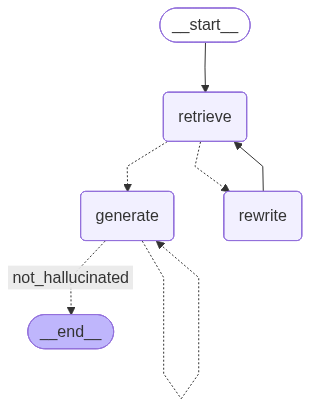

In [48]:
from langgraph.graph import StateGraph, START, END

# 그래프 생성
graph_builder = StateGraph(AgentState)

# 노드 추가
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

# 엣지 연결
graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevence,
    {
        'generate': 'generate',
        'rewrite': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'not_hallucinated': END,
        'generate': 'generate'
    }
)

# 그래프 컴파일
graph = graph_builder.compile()

# 그래프 시각화
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
result = graph.invoke({'query': '연봉 5천만원 거주자의 소득세는 얼마인가요'})
print("=== 최종 답변 ===")
print(result['answer'])

c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


--- 문서 관련성: 관련 있음 → generate ---
